## Data Preprocessing
<p>prepare raw data so that model learn correctly</p>
<b>Why preprocessing is required?</b>
<ul>
<li>Missing values</li>
<li>Different scales</li>
<li>Categorical features</li>

In [4]:
import pandas as pd
from sklearn.datasets import fetch_openml

titanic=fetch_openml(name="titanic",version=1)
df=titanic.frame


## 1. Understand your data

In [5]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 116.5 KB


pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

## 2. Removing the use less columns
<b>name, ticket, cabin:</b>
<ul>
<li>Too many unique values (high cardinality)</li>
<li>No strong predictive pattern (noise)</li>
</ul>
<b>Garbage features = bad model</b>

In [6]:

df.drop(columns=["name","ticket","cabin"],inplace=True)

## 3. Separate features and target
<p>axis=1, when working with "colums"<p>
<p>axis=0, when working with "rows"<p>

In [7]:

X=df.drop("survived",axis=1)
y=df["survived"]

## 4. identify different column types
<p>Categorise colums on the basis of there datatype so that we can perform scaling on numerical colums and encoding on categorical data at once.</p>

<b>why?</b>
<p>Different types → different preprocessing:<p>
<ul>
    <li>Numbers → scaling</li>
    <li>Categories → encoding</li>
</ul>

In [8]:
nums_cols=X.select_dtypes(include=["int64","float64"]).columns
cat_cols=X.select_dtypes(include=["object","category"]).columns
print("nums columns:",nums_cols)
print("cat columns:",cat_cols)

nums columns: Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'body'], dtype='str')
cat columns: Index(['sex', 'embarked', 'boat', 'home.dest'], dtype='str')


C:\Users\mysel\AppData\Local\Temp\ipykernel_14404\3398321666.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(include=["object","category"]).columns


## 5. handle missing values
we handle missing values using imputer, it replace the null data with appropiate data derived from the existing data that is not null in the data frame.<br>

<b>Why?</b>
<ul>
    <li>Mean → keeps distribution stable</li>
    <li>Mode → most logical category fill</li>
    <li>ML cannot handle NaN</li>
</ul>

In [9]:
from sklearn.impute import SimpleImputer
nums_imputer=SimpleImputer(strategy="mean")
cat_imputer=SimpleImputer(strategy="most_frequent")

# imputing columns with values
X[nums_cols]=nums_imputer.fit_transform(X[nums_cols])
X[cat_cols]=cat_imputer.fit_transform(X[cat_cols])


## 6. Encoding (REAL WAY, not manual)
<ul>
    <li><b>One-Hot Encoding:</b> Converts categorical variables into binary vectors, avoiding ordinal assumptions.</li>
    <li><b>Drop First:</b> Removes one column to prevent multicollinearity in linear models.</li>
    <li><b>Sparse Output:</b> Uses dense arrays for compatibility with most ML algorithms.</li>
    <li><b>Feature Names:</b> Generates meaningful column names from original categories.</li>
    <li><b>Integration:</b> Concatenates encoded features back to numerical data for complete preprocessing.</li>
</ul>

In [10]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(drop="first",sparse_output=False)

# returns encoded matrix
encoded=encoder.fit_transform(X[cat_cols])
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out(cat_cols))

X=X.drop(columns=cat_cols)
X=pd.concat([X,encoded_df],axis=1)


## 7. feature scaling

Feature scaling is a crucial preprocessing step in machine learning that standardizes the range of independent variables or features. It ensures that all features contribute equally to the model's performance by transforming them to a common scale, preventing features with larger magnitudes from dominating the learning process. Common techniques include standardization (e.g., using StandardScaler to center data around mean 0 with unit variance) and normalization (e.g., Min-Max scaling to a fixed range like [0,1]). This is especially important for algorithms sensitive to feature scales, such as linear regression, logistic regression, and distance-based methods like KNN or SVM, helping to improve convergence speed and model accuracy.

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[nums_cols]=scaler.fit_transform(X[nums_cols])

## 8. Splitting data

In [12]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)


## 9. Training Model

In [13]:

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 10. Prediction using model

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error
y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))


0.837630747282568
0.10577307273277733



##  R² Score (Coefficient of Determination)

**Definition:**
R² measures how well the model explains the variance in the target variable.

**Formula:**

```math
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
```

**Where:**

* ( y_i ) = actual value
* ( \hat{y}_i ) = predicted value
* ( \bar{y} ) = mean of actual values

---

##  Variance

**Definition:**
Variance measures how much the data points spread out from the mean.

**Formula:**

```math
\mathrm{Var}(X) = \frac{1}{n} \sum (x_i - \mu)^2
```

**Where:**

* ( x_i ) = data point
* ( \mu ) = mean
* ( n ) = number of data points

---

## Standard Deviation

**Definition:**
Standard deviation is the square root of variance, representing spread in the same unit as data.

**Formula:**

```math
\sigma = \sqrt{\frac{1}{n} \sum (x_i - \mu)^2}
```

---

## Quick Intuition

* **Variance** → spread (squared units)
* **Standard Deviation** → spread (original units)
* **R²** → how well model explains that spread



<hr>

<h2>2. Logistic Regression</h2>

<ul>
  <li>Supervised Machine Learning algorithm</li>
  <li>Used to solve classification problems</li>
  <li>Outcome is binary (0 or 1)</li>
  <li>No missing values are allowed (must be handled during preprocessing)</li>
</ul>

<p>
  We first get a linear continuous result:
  <i>z = b + b1x1 + b2x2 + b3x3 + ... + bnxn</i>
</p>

<p>
  Then we pass this value to the sigmoid function:
</p>

<p>
  <i>y = 1 / (1 + e<sup>-z</sup>)</i>
</p>

<p>
  The output value lies between <b>[0, 1]</b> and forms an 
  <b>S-shaped (sigmoid) curve</b> where 
  <i>x ∈ (-∞, +∞)</i>
</p>

<p><b>Logic:</b></p>

<pre>
if (y > 0.5)
    return 1
else
    return 0
</pre>

<hr>

<h3>Real-World Intuition</h3>

<p>
  Real-world decisions are <b>not linear</b>.
</p>

<p><b>Example:</b></p>

<ul>
  <li>As salary increases → buying probability increases</li>
  <li>But not instantly → it increases gradually</li>
</ul>

In [29]:
# 1.Logistic Regression on the same data set

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

# 2. Train model
model.fit(X_train,y_train)

# What just happened?
# Model learned patterns like:
# females survived more
# higher class → more survival
# age impact
# It’s finding a decision boundary

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
# 3. Prediction 
pred=model.predict(X_test)

In [31]:
# testing accuracy
# What just happened?
# Model learned patterns like:
# females survived more
# higher class → more survival
# age impact
# It’s finding a decision boundary

# 4. Accuracy
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,pred)
print("accuracy:",acc*100,"%")

accuracy: 95.80152671755725 %


In [32]:
# 5. confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

#         Predicted
#         0    1
# Actual
# 0      TN   FP
# 1      FN   TP

# TN → correctly predicted dead
# TP → correctly predicted survived
# FP → predicted survived but died 
# FN → predicted died but survived 

[[144   0]
 [ 11 107]]


In [33]:
# 6. Full report
from sklearn.metrics import classification_report
report=classification_report(y_test,pred)
print(report)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       144
           1       1.00      0.91      0.95       118

    accuracy                           0.96       262
   macro avg       0.96      0.95      0.96       262
weighted avg       0.96      0.96      0.96       262



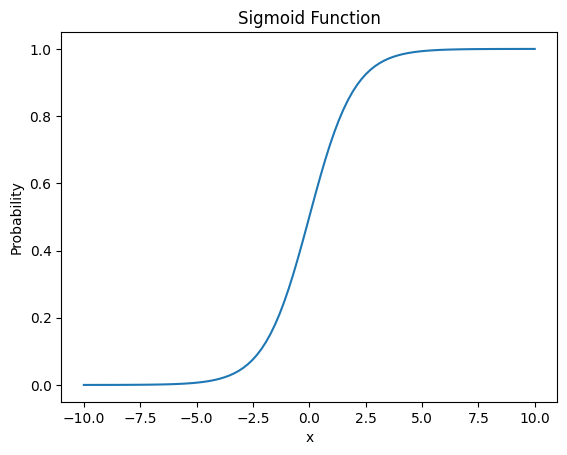

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Sigmoid Function")
plt.show()